# **Seeing the Invisible: Fourier Transform and Its Application in Radio Astronomy**
### Lecture for DARA's Students

**Instructor:** Theophilus Ansah-Narh  
**Objective:** Understand how the Fourier Transform provides the mathematical foundation for signal processing and image reconstruction in radio astronomy.


---




## Outline

1. 1D Fourier Transform – Theory and Examples  
2. Denoising with the Fourier Transform  
3. 2D Fourier Transform – Images, Amplitude & Phase  
4. Fourier Transform in Radio Astronomy  
5. Sky Simulation, Sampling, and Reconstruction  
6. Take-home Summary


# **Section 1: 1D Fourier Transform — Understanding the Basics**

### Mathematical Foundation

The **Fourier Transform** of a time-domain signal \( f(t) \) is:

$$
F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-i\omega t} dt
$$

The **Inverse Fourier Transform** reconstructs the signal:

$$
f(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} F(\omega) e^{i\omega t} d\omega
$$

**Key idea:**
> Any signal can be represented as a weighted sum of sinusoids of different frequencies.


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Time grid
# t = np.linspace(-5, 5, 1024)
# dt = t[1] - t[0]
# freq = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

# # Example signals
# delta = np.zeros_like(t)
# delta[len(t)//2] = 1  # Delta function

# rect = np.where(np.abs(t) <= 1, 1, 0)
# tri = np.maximum(0, 1 - np.abs(t))
# gauss = np.exp(-t**2)

# signals = {'Delta': delta, 'Rectangular': rect, 'Triangular': tri, 'Gaussian': gauss}

# fig, axs = plt.subplots(len(signals), 2, figsize=(10, 10))
# for i, (name, sig) in enumerate(signals.items()):
#     fft_sig = np.fft.fftshift(np.fft.fft(sig))
#     axs[i, 0].plot(t, sig)
#     axs[i, 0].set_title(f"{name} Signal")
#     axs[i, 1].plot(freq, np.abs(fft_sig))
#     axs[i, 1].set_title(f"{name} |FT| Spectrum")
# plt.tight_layout()
# plt.show()


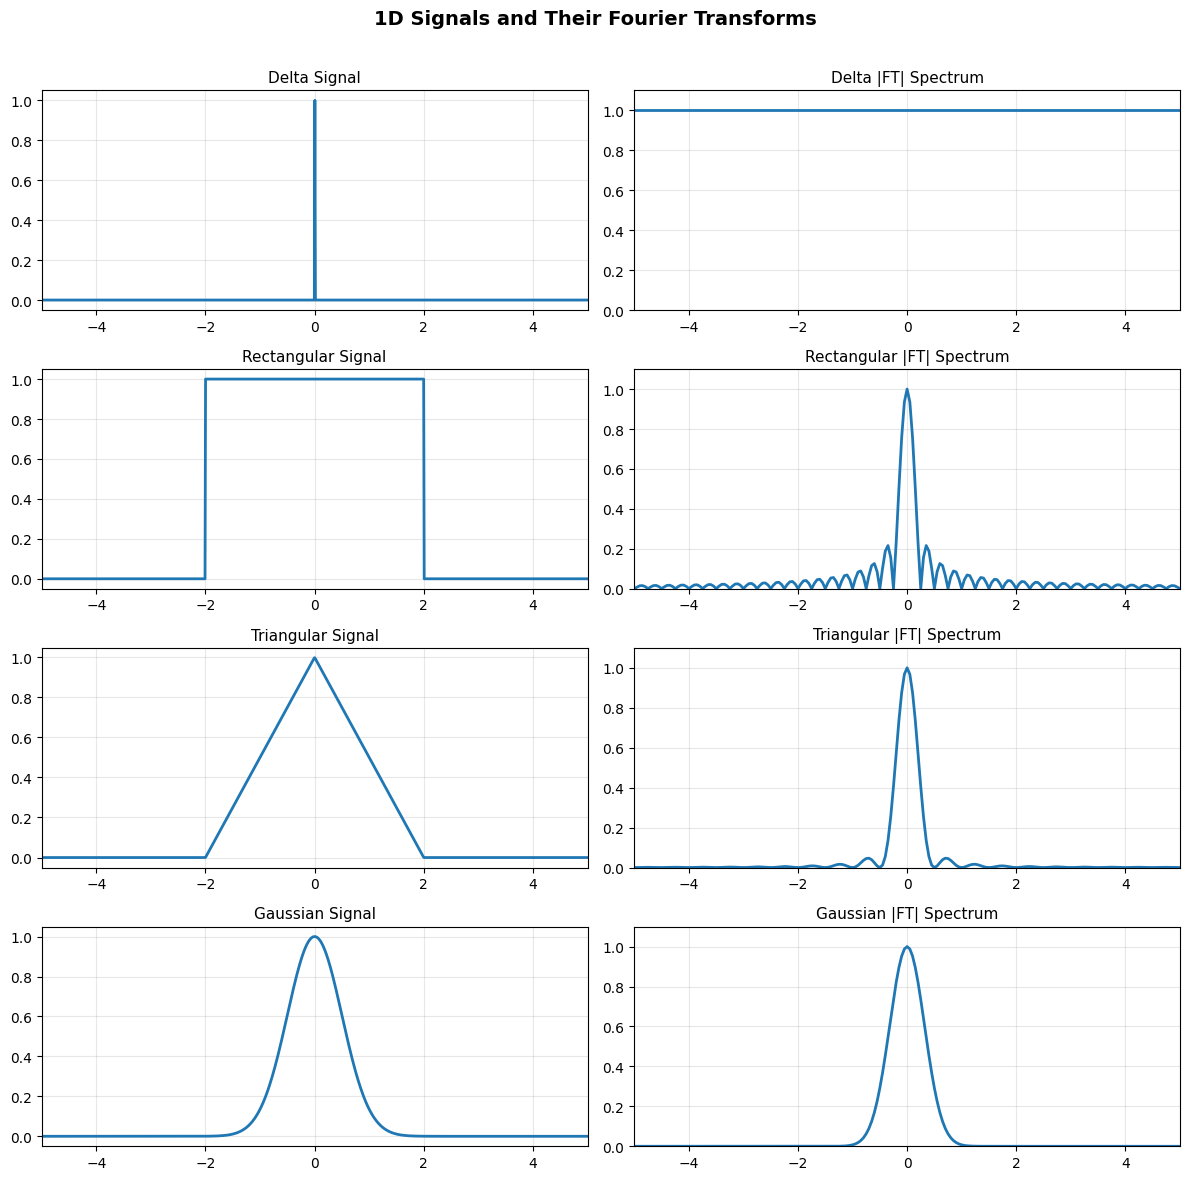

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time grid
t = np.linspace(-10, 10, 2048)  # wider range for better frequency resolution
dt = t[1] - t[0]
freq = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

# Define signals
delta = np.zeros_like(t)
delta[len(t)//2] = 1

rect = np.where(np.abs(t) <= 2, 1, 0)
tri = np.maximum(0, 1 - np.abs(t)/2)
gauss = np.exp(-t**2 / (2 * 0.5**2))

signals = {'Delta': delta, 'Rectangular': rect, 'Triangular': tri, 'Gaussian': gauss}

# Plot
fig, axs = plt.subplots(len(signals), 2, figsize=(12, 12))

for i, (name, sig) in enumerate(signals.items()):
    fft_sig = np.fft.fftshift(np.fft.fft(sig))
    fft_mag = np.abs(fft_sig) / np.max(np.abs(fft_sig))  # normalize for visibility

    axs[i, 0].plot(t, sig, lw=2)
    axs[i, 0].set_xlim(-5, 5)
    axs[i, 0].set_title(f"{name} Signal", fontsize=11)
    axs[i, 0].grid(True, alpha=0.3)

    axs[i, 1].plot(freq, fft_mag, lw=2)
    axs[i, 1].set_xlim(-5, 5)
    axs[i, 1].set_ylim(0, 1.1)
    axs[i, 1].set_title(f"{name} |FT| Spectrum", fontsize=11)
    axs[i, 1].grid(True, alpha=0.3)

fig.suptitle("1D Signals and Their Fourier Transforms", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



##  **Understanding the Plots**

###  **1. Delta Function**

* **Signal domain (left):**
  A single, sharp pulse (infinitely narrow and strong).
* **Fourier domain (right):**
  The transform is *flat* across all frequencies — every frequency component is present equally.
* **Interpretation:**

  * A delta function in time (or sky) corresponds to equal contributions at all frequencies in the Fourier domain.
  * **In radio astronomy:**
    A **point source** in the sky contributes equally to all spatial frequencies — it produces **flat visibilities** across all baselines.

---

###  **2. Rectangular Function**

* **Signal domain (left):**
  A finite-width “box” or window — sharp edges.
* **Fourier domain (right):**
  A **sinc function** with clear **sidelobes** that decay slowly.
* **Interpretation:**

  * Sharp transitions in the signal cause high-frequency oscillations in the spectrum (Gibbs phenomenon).
  * **In radio astronomy:**
    A telescope aperture with a sharp edge (like a circular dish) has a sinc-like **beam pattern** — leading to **sidelobes** in the sky response.
  * Sidelobes cause contamination: bright sources can “leak” into neighbouring regions of the sky image.

---

###  **3. Triangular Function**

* **Signal domain (left):**
  A smoother version of the rectangular pulse — continuous and linearly decaying.
* **Fourier domain (right):**
  A sinc²-shaped spectrum — narrower and smoother, with sidelobes more strongly suppressed.
* **Interpretation:**

  * Smoother functions yield fewer high-frequency components and better sidelobe suppression.
  * **In radio astronomy:**
    Applying **apodization or tapering** (smoothing the edges of the aperture or visibility weighting) reduces sidelobes in the synthesized beam, improving dynamic range.

---

### 🔹 **4. Gaussian Function**

* **Signal domain (left):**
  A smooth, bell-shaped curve with no sharp transitions.
* **Fourier domain (right):**
  A Gaussian again — self-similar under Fourier transform.
* **Interpretation:**

  * The Gaussian is its own Fourier transform: smooth in both domains, no oscillations.
  * **In radio astronomy:**

    * A **Gaussian primary beam** (or Gaussian taper) yields a clean Fourier response.
    * Used to model the **point spread function (PSF)** or telescope **beam pattern**.
    * Gaussian weighting in the ( u,v )-plane produces well-behaved image reconstructions.

---

##  **Connecting to Radio Astronomy**

| Concept                     | Signal Analogy                | Fourier Domain Analogy           | Radio Astronomy Meaning                             |
| --------------------------- | ----------------------------- | -------------------------------- | --------------------------------------------------- |
| **Sky Brightness**          | The signal ( f(x,y) )         | Its Fourier transform ( F(u,v) ) | Sky ↔ Visibility relation                           |
| **Point Source**            | Delta function                | Flat spectrum                    | Equal response across baselines                     |
| **Extended Source**         | Wide rectangular or Gaussian  | Narrower FT                      | Visibility amplitude decreases with baseline length |
| **Telescope Beam**          | Aperture shape                | Beam pattern (sinc or Gaussian)  | Determines angular resolution and sidelobes         |
| **Aperture Tapering**       | Triangular/Gaussian weighting | Reduced sidelobes                | Improves dynamic range of image                     |
| **Interferometer Sampling** | Sparse measurement            | Partial FT coverage              | Incomplete sky information (needs inverse FT)       |

---




# Section 2: Denoising a Signal with Fourier Transform

Real signals are noisy. The Fourier Transform can isolate noise by removing weak spectral components using a threshold on the **Power Spectral Density (PSD)**.


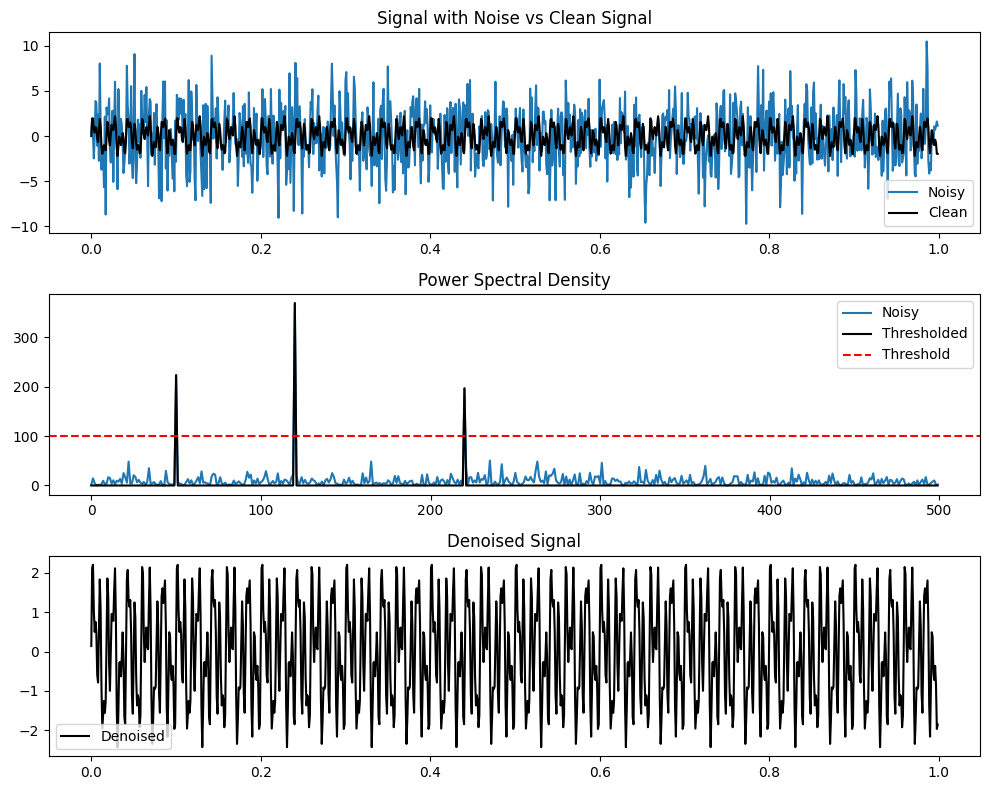

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time parameters
dt = 0.001
t = np.arange(0, 1, dt)
n = len(t)

# Angular frequencies
w = 2 * np.pi * np.array([50, 120, 220])
f = np.sum(np.sin(w[:, None] * t), 0)  # clean signal

# Add Gaussian noise
fn = f + 3 * np.random.randn(n)

# FFT
h = np.fft.fft(fn, n)
PSD = h * np.conj(h) / n
freq = (1 / (dt * n)) * np.arange(n)

# Threshold
PSD0 = np.where(PSD < 100, 0, PSD)
h = np.where(PSD < 100, 0, h)
H = np.fft.ifft(h)

# Plot
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(t, fn, label='Noisy')
ax[0].plot(t, f, c='k', label='Clean')
ax[0].set_title('Signal with Noise vs Clean Signal'); ax[0].legend()

m = n // 2
ax[1].plot(freq[:m], PSD[:m], label='Noisy')
ax[1].plot(freq[:m], PSD0[:m], c='k', label='Thresholded')
ax[1].axhline(100, ls='--', c='r', label='Threshold'); ax[1].legend()
ax[1].set_title('Power Spectral Density')

ax[2].plot(t, H.real, c='k', label='Denoised')
ax[2].set_title('Denoised Signal'); ax[2].legend()
plt.tight_layout()
plt.show()


# Section 3: 2D Fourier Transform — From Signals to Images

In 2D, the Fourier Transform converts spatial intensity patterns into spatial frequency components.

$$
F(u, v) = \iint f(x, y) e^{-2\pi i(ux + vy)} dx\,dy
$$
$$
f(x, y) = \iint F(u, v) e^{2\pi i(ux + vy)} du\,dv
$$

Each point \((u, v)\) in the Fourier plane corresponds to a sinusoidal pattern in the image.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import os

new_directory_path = "drive/MyDrive/Untitled folder/"

try:
    os.chdir(new_directory_path)
    print(f"Successfully changed working directory to:\n{os.getcwd()}")
except FileNotFoundError:
    print(f"Error: The directory was not found: {new_directory_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully changed working directory to:
/content/drive/MyDrive/Untitled folder


In [16]:
!pwd

/content/drive/MyDrive/Untitled folder


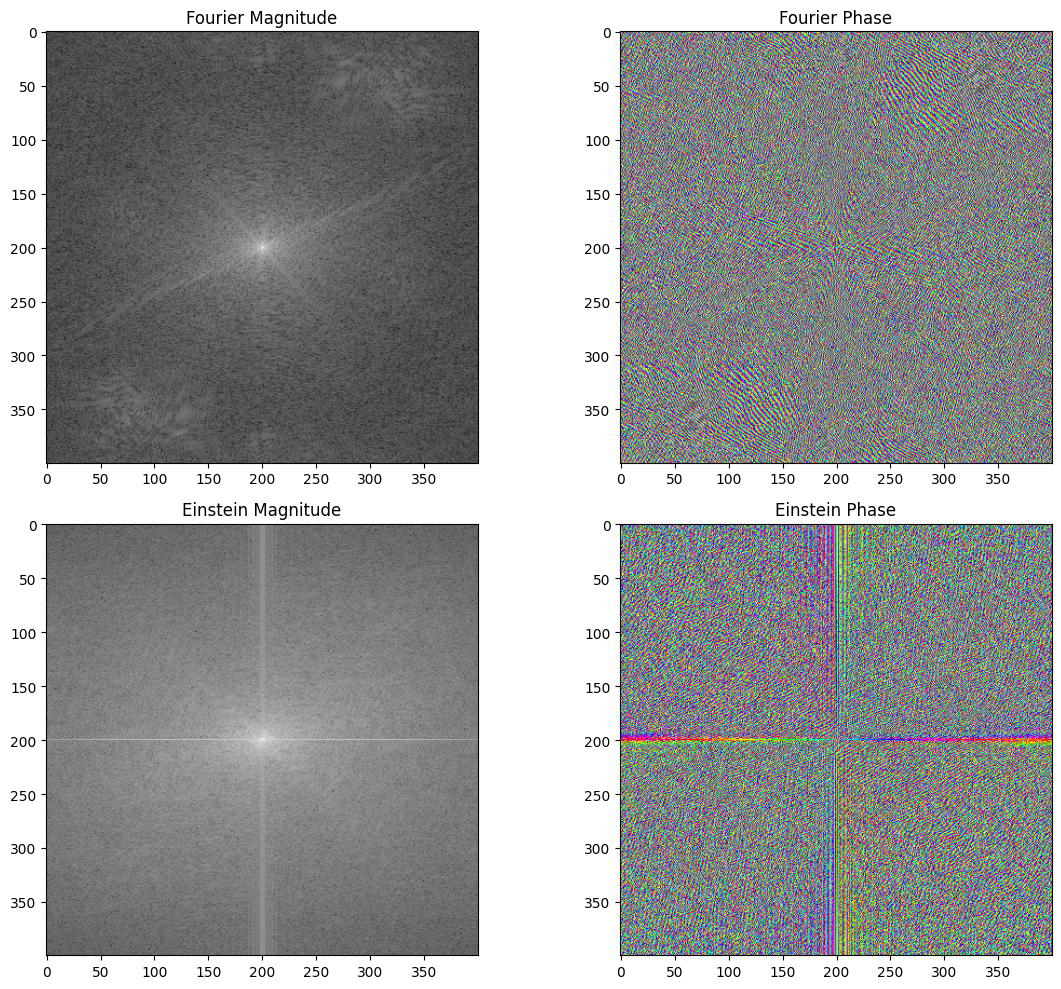

In [17]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image

def rgb2gray(rgb):
    return 0.2989 * rgb[...,0] + 0.5870 * rgb[...,1] + 0.1140 * rgb[...,2]

def resize_image(image, size=(400, 400)):
    return np.array(Image.fromarray(image).resize(size))

# Load and process images
img0 = mpimg.imread('img/fourier.jpeg')[:,:,:3]
img1 = mpimg.imread('img/einstein.png')[:,:,:3]
gimg0 = resize_image(rgb2gray(img0))
gimg1 = resize_image(rgb2gray(img1))

# FFT and visualize
fft0 = np.fft.fftshift(np.fft.fft2(gimg0))
fft1 = np.fft.fftshift(np.fft.fft2(gimg1))

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes[0,0].imshow(10*np.log10(np.abs(fft0)), cmap='gray'); axes[0,0].set_title('Fourier Magnitude')
axes[0,1].imshow(np.angle(fft0), cmap='hsv'); axes[0,1].set_title('Fourier Phase')
axes[1,0].imshow(10*np.log10(np.abs(fft1)), cmap='gray'); axes[1,0].set_title('Einstein Magnitude')
axes[1,1].imshow(np.angle(fft1), cmap='hsv'); axes[1,1].set_title('Einstein Phase')
plt.tight_layout(); plt.show()



## **Understanding the 2D Fourier Transform: Amplitude and Phase**

For any 2D image ( f(x, y) ), the **Fourier Transform** is a complex function:

$$
F(u, v) = A(u, v) e^{i\phi(u, v)}
$$

where:

* $ A(u, v) = |F(u, v)| $ is the **magnitude (amplitude)** spectrum
* $ \phi(u, v) = \text{arg}(F(u, v)) $ is the **phase** spectrum

Together, these encode **all information** about the image.

---

## **(1) Fourier Amplitude (Magnitude Spectrum)**

**Panels:** *Top-left (Fourier)* and *Bottom-left (Einstein)*

**What it shows:**

* The **brightness** near the centre corresponds to **low spatial frequencies** (large-scale structures, smooth gradients).
* **High frequencies** (fine details, edges, texture) appear farther from the centre.
* The pattern is **symmetric** about the centre because real images have Hermitian (mirror) symmetry in the Fourier domain.

**Interpretation:**

* Bright central spot → overall smooth background.
* Faint streaks or cross structures → presence of sharp edges or directional features (horizontal/vertical lines).
* The Einstein image’s strong **vertical and horizontal streaks** mean it has sharp edges and fine details aligned with those directions.

**Analogy in Radio Astronomy:**

* $ |F(u,v)| $ corresponds to **visibility amplitude** — how much “power” the sky brightness contributes at each baseline length.
* Low $ |u,v| $ → large-scale emission; high $ |u,v| $ → small-scale structure.
* A bright, compact source (point-like) has strong high-frequency amplitudes, while diffuse emission falls off quickly.

---

## **(2) Fourier Phase (Phase Spectrum)**

**Panels:** *Top-right (Fourier)* and *Bottom-right (Einstein)*

**What it shows:**

* Each pixel encodes the **relative phase** (position) of sinusoids that build up the image.
* It looks “random” or noisy, but it actually contains the **structural geometry** of the image.
* The **fine coloured interference-like patterns** represent spatial alignment information (edges, object outlines).

**Interpretation:**

* The phase determines *where* features appear in the image.
* Two images with identical amplitudes but swapped phases will look like the one whose phase you kept — phase dominates image identity.

**Analogy in Radio Astronomy:**

* In interferometry, the **phase of each visibility** encodes the position of structures in the sky.
* Accurate calibration of **phase** (e.g., correcting atmospheric delay, instrument offsets) is crucial — even small phase errors cause **image distortions or blurring**.
* Without correct phase, you cannot reconstruct a meaningful image, even if amplitudes are perfect.

---

##  **Fourier vs Einstein Comparison**

| Aspect                     | Fourier Image (Top)                                                                               | Einstein Image (Bottom)                                                                                                          |
| -------------------------- | ------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **Amplitude**              | Smooth central peak with diagonal streaks — implies edges and gradients at specific orientations. | Strong vertical/horizontal streaks — Einstein’s portrait has many sharp edges and aligned features.                              |
| **Phase**                  | Appears random but encodes alignment of those diagonals and features.                             | Phase more structured with vertical and horizontal bands — corresponding to the high-contrast facial features and hair outlines. |
| **Reconstruction Insight** | If you swap the amplitudes but keep the phase — you see Einstein.                                 | Phase defines geometry; amplitude defines contrast.                                                                              |

---

##  **Radio Astronomy Analogy**

| Fourier Concept             | Radio Astronomy Term      | Physical Meaning                              |                      |                                                             |
| --------------------------- | ------------------------- | --------------------------------------------- | -------------------- | ----------------------------------------------------------- |
| Image intensity $ f(x,y) $  | Sky brightness $ I(l,m) $ | True radio sky image                          |                      |                                                             |
| Fourier amplitude $         | F(u,v)                    | $                                             | Visibility amplitude | How strong the signal is at each baseline (structure scale) |
| Fourier phase $ \phi(u,v) $ | Visibility phase          | Position information of features              |                      |                                                             |
| Low spatial frequency       | Short baselines           | Sensitive to diffuse, extended emission       |                      |                                                             |
| High spatial frequency      | Long baselines            | Sensitive to compact sources and fine details |                      |                                                             |

---

###  **Summary Takeaway**

> * **Amplitude** controls *how much* of each spatial frequency is present.
> * **Phase** controls *where* each structure is located.
> * Without correct phase, the image loses structure.
> * In radio astronomy, **phase calibration** is as vital as **amplitude calibration** — together they reconstruct the sky.



# Section 4: Phase–Amplitude Reconstruction

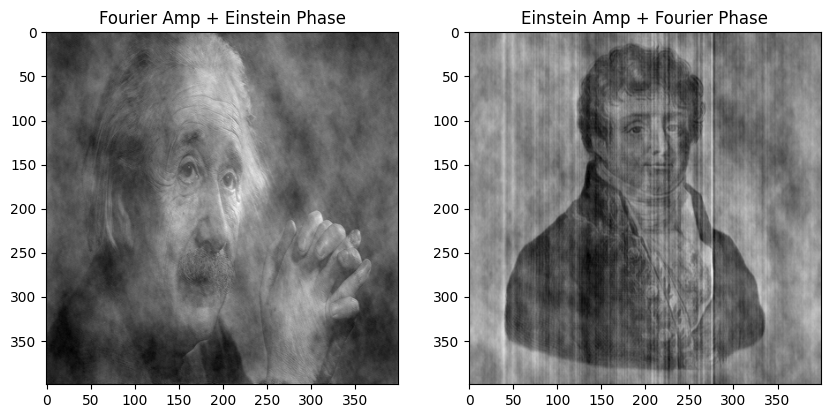

In [18]:
# Hybrid 1: Amplitude (Fourier), Phase (Einstein)
hybrid1 = np.fft.ifft2(np.fft.fftshift(np.abs(fft0) * np.exp(1j * np.angle(fft1)))).real

# Hybrid 2: Amplitude (Einstein), Phase (Fourier)
hybrid2 = np.fft.ifft2(np.fft.fftshift(np.abs(fft1) * np.exp(1j * np.angle(fft0)))).real

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(hybrid1, cmap='gray'); ax[0].set_title('Fourier Amp + Einstein Phase')
ax[1].imshow(hybrid2, cmap='gray'); ax[1].set_title('Einstein Amp + Fourier Phase')
plt.show()


### Observation:
Even when the amplitude comes from one image, the **phase** controls most of the structure.  
This is critical for radio interferometry: **phase = positional information**, **amplitude = intensity.**


# **Section 5: Fourier Transform and Radio Astronomy**

Radio telescopes (interferometers) measure **visibilities**:

$$
V(u, v) = \iint I(l, m) e^{-2\pi i (ul + vm)} dl\,dm
$$

- $ I(l, m) $: Sky brightness distribution  
- $ (u, v) $: Baseline coordinates (spatial frequency space)

Each antenna pair measures one Fourier component of the sky.
The final image is the **inverse Fourier transform** of all visibilities.


# Simulating a Simple Sky

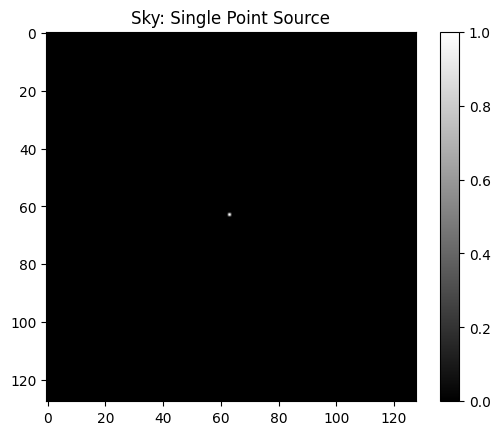

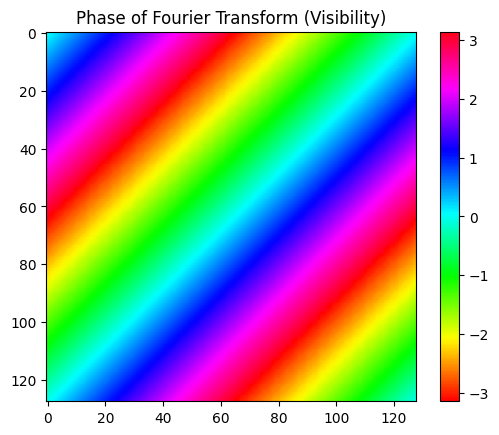

In [19]:
sky = np.zeros((128,128))
sky[63,63] = 1.0  # point source
plt.imshow(sky, cmap='gray'); plt.title('Sky: Single Point Source'); plt.colorbar(); plt.show()

# Fourier Transform
Fsky = np.fft.fft2(np.fft.fftshift(sky))
plt.imshow(np.angle(Fsky), cmap='hsv'); plt.title('Phase of Fourier Transform (Visibility)'); plt.colorbar(); plt.show()


Perfect — these plots are an **ideal illustration** of the Fourier-domain properties of a single point source in the sky. Here’s how you can **explain the amplitude and phase patterns** clearly in class:

---

## 🌌 **Fourier Amplitude and Phase of a Single Point Source**

### 🔹 **Sky Image (Left Panel)**

* A single bright pixel represents a **point source** — a perfect delta function in real (sky) space.
* Physically, this means all emission comes from one direction (single spatial coordinate).

---

### 🔹 **Amplitude Spectrum (Middle/Left Plot)**

* The amplitude (|F|) is **constant across all spatial frequencies (u,v)**.
* Mathematically, the Fourier transform of a delta function is a **flat spectrum**:
  [
  \mathcal{F}{\delta(x, y)} = 1
  ]
* This means the point source contributes **equally to all spatial frequencies** — no structure, so every baseline measures the same visibility amplitude.

**In Radio Astronomy:**

* A single unresolved source appears with **uniform visibility amplitude** across all baselines.
* In practice, a bright quasar or compact galaxy looks like this to an interferometer.

---

### 🔹 **Phase Spectrum (Right Plot)**

* The phase pattern appears as **smooth diagonal colour bands**, representing a **linear phase gradient**.
* The gradient arises because the point is not exactly at the mathematical origin (centre of the array).
* Shifting a delta function in the sky introduces a phase term:
  $$
  F(u, v) = e^{-2\pi i(ul_0 + vm_0)}
  $$
  where $(l_0, m_0)$ is the sky position of the point source.
* The further the source is from the centre, the faster the phase changes with $(u,v)$.

**In Radio Astronomy:**

* This phase gradient encodes the **position of the source** on the sky.
* A perfectly centred source (at the phase-tracking centre) gives **zero phase everywhere**.
* Phase calibration ensures all sources align correctly; any offset creates **fringes** (phase oscillations).

---

###  **Key Takeaway**

> * A point source corresponds to a **flat Fourier amplitude** and a **linear phase gradient**.
> * In an interferometer, **amplitude tells us how bright**, **phase tells us where**.
> * Image reconstruction is thus about correctly recovering both amplitude and phase of visibilities.



# Multiple Sources and Gaussian Sky

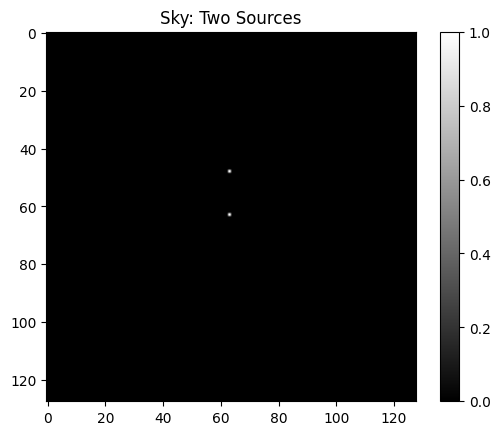

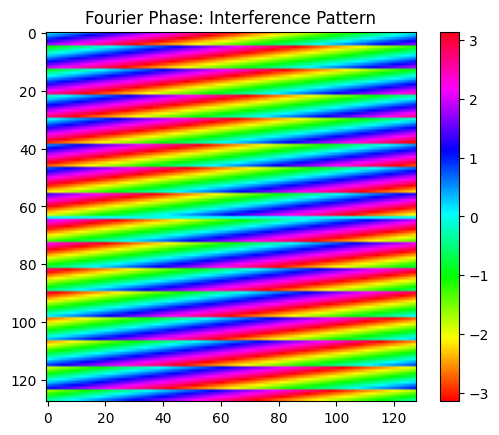

In [20]:
sky = np.zeros((128,128))
sky[48,63] = 1.0
sky[63,63] = 1.0
plt.imshow(sky, cmap='gray'); plt.title('Sky: Two Sources'); plt.colorbar(); plt.show()

Fsky = np.fft.fft2(np.fft.fftshift(sky))
plt.imshow(np.angle(Fsky), cmap='hsv'); plt.title('Fourier Phase: Interference Pattern'); plt.colorbar(); plt.show()


# **Take-Home Summary**

### Key Insights

1. **Fourier Transform** decomposes signals into frequency components.
2. **Phase** contains structure and positional information; **amplitude** holds intensity.
3. **In radio interferometry**, visibilities are Fourier components of the sky brightness.
4. **Inverse Fourier Transform** reconstructs the image of the sky.
5. **Sampling (u,v) coverage** determines image quality; missing data causes sidelobes and distortions.
6. **Fourier filtering** enables denoising and beam shaping in astronomical data processing.

---

> “Every image a radio telescope sees is reconstructed from its Fourier eyes.”
